In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## (i) Create the two 3x3 uint8 patches from part (a)


In [2]:
A = np.array([[250, 10, 90], [60, 200, 30], [15, 5, 180]], dtype=np.uint8)
B = np.array([[20, 250, 40], [80, 90, 220], [10, 240, 90]], dtype=np.uint8)

print("Patch A:\n", A)
print("\nPatch B:\n", B)

Patch A:
 [[250  10  90]
 [ 60 200  30]
 [ 15   5 180]]

Patch B:
 [[ 20 250  40]
 [ 80  90 220]
 [ 10 240  90]]


## (ii) Plain NumPy addition -> wrap-around (modulo 256) behavior


In [3]:
numpy_sum = A + B  # uint8 + uint8 wraps around silently on overflow
print("[NumPy]  A + B  (wrap-around / modulo-256):\n", numpy_sum)

[NumPy]  A + B  (wrap-around / modulo-256):
 [[ 14   4 130]
 [140  34 250]
 [ 25 245  14]]


## (iii) cv2.add -> saturation behavior


In [4]:
opencv_sum = cv2.add(A, B)  # clips to 255 on overflow
print("[OpenCV] cv2.add(A, B)  (saturation):\n", opencv_sum)

[OpenCV] cv2.add(A, B)  (saturation):
 [[255 255 130]
 [140 255 250]
 [ 25 245 255]]


## (iv) Subtraction: NumPy (wrap-around) vs cv2.subtract (saturation)


In [5]:
numpy_diff = A - B  # underflow wraps around (e.g. 10 - 250 -> 16 mod 256)
opencv_diff = cv2.subtract(A, B)  # negative results clipped to 0

print("[NumPy]  A - B  (wrap-around):\n", numpy_diff)
print("\n[OpenCV] cv2.subtract(A, B)  (saturation):\n", opencv_diff)

# Compare the two subtraction results element-wise
diff_mismatch_mask = numpy_diff != opencv_diff
print(
    "\nPositions where NumPy and OpenCV subtraction differ (True = differ):\n",
    diff_mismatch_mask,
)

[NumPy]  A - B  (wrap-around):
 [[230  16  50]
 [236 110  66]
 [  5  21  90]]

[OpenCV] cv2.subtract(A, B)  (saturation):
 [[230   0  50]
 [  0 110   0]
 [  5   0  90]]

Positions where NumPy and OpenCV subtraction differ (True = differ):
 [[False  True False]
 [ True False  True]
 [False  True False]]


## (v) cv2.addWeighted() to blend two real grayscale images


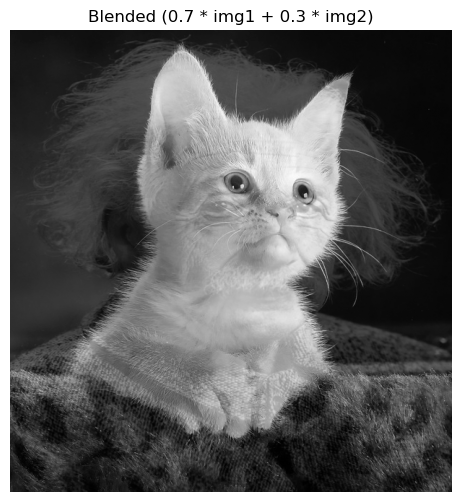

In [6]:
img1_path = "images/image1.jpg"
img2_path = "images/image2.jpg"

img1 = cv2.imread(img1_path, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(img2_path, cv2.IMREAD_GRAYSCALE)

if img1 is not None and img2 is not None:
    if img1.shape != img2.shape:
        # Resize img2 to match img1 so addWeighted can operate on them
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    blended = cv2.addWeighted(img1, 0.7, img2, 0.3, 0)

    plt.figure(figsize=(6, 6))
    plt.imshow(blended, cmap="gray")
    plt.title("Blended (0.7 * img1 + 0.3 * img2)")
    plt.axis("off")
    plt.show()
else:
    print(f"[Skipped step v] Could not load '{img1_path}' and/or '{img2_path}'.")
    print(
        "Place two same-size grayscale images with these filenames in the "
        "working directory to run the addWeighted() blending demo."
    )

## (vi) Discussion: NumPy vs OpenCV arithmetic on uint8 data

NumPy performs raw modular (wrap-around) arithmetic on uint8 arrays: when a sum exceeds 255, it silently overflows and wraps back into the 0-255 range (`result = (a + b) mod 256`). Similarly, when a difference goes below 0, it wraps upward toward 255 (underflow). This happens because NumPy treats uint8 as a fixed-width integer type and does not check for overflow.

OpenCV's `cv2.add()` and `cv2.subtract()`, by contrast, apply **SATURATION** arithmetic: results are clipped to the valid range `[0, 255]` rather than wrapping. A sum greater than 255 is capped at 255 (white); a difference less than 0 is capped at 0 (black).

In the results above:

- Every pixel where $A + B \ge 256$ differs between `numpy_sum` and `opencv_sum`. NumPy shows a small wrapped value; OpenCV shows 255.
- Every pixel where $A - B < 0$ differs between `numpy_diff` and `opencv_diff`. NumPy shows a large wrapped value (near 255); OpenCV shows 0.
- Pixels where the true sum/difference already falls inside `[0, 255]` are **IDENTICAL** between NumPy and OpenCV, since no overflow/underflow occurs.

This matters in real image processing because wrap-around introduces visual artifacts unrelated to the scene (bright pixels can wrap into dark ones and vice versa), whereas saturation arithmetic matches how real sensors/displays behave (clipping at min/max brightness) and keeps images visually coherent.
